``My mission:``
Improving agricultural productivity by predicting crop yield based on environmental conditions and farming practices.

``Problem statement:``
Agriculture is one of the largest contributors to African economies. Predicting crop yield using weather conditions, soil type, irrigation, fertilizer use, and farming practices can help farmers make better decisions to increase production and reduce losses.


In [2]:
## First loading the dataset and getting to know it better

import pandas as pd

df = pd.read_csv('../crop_yield.csv')
df.head()


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [3]:
## Exploring the dataset
df.shape

(1000000, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB


In [5]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


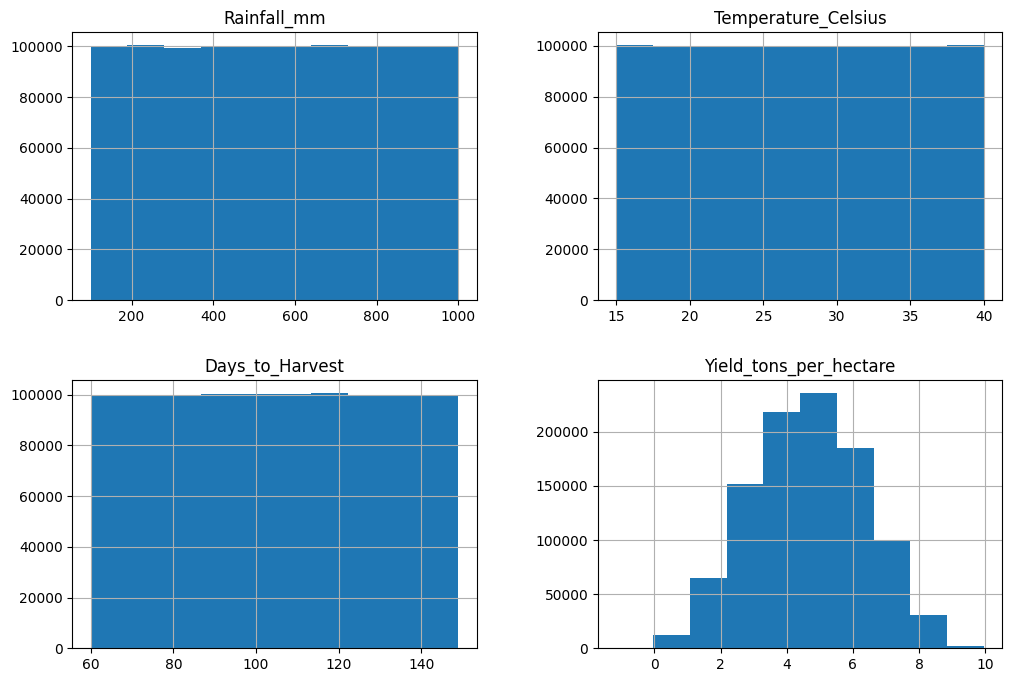

In [6]:
## Visualizing the data distribution
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.show()

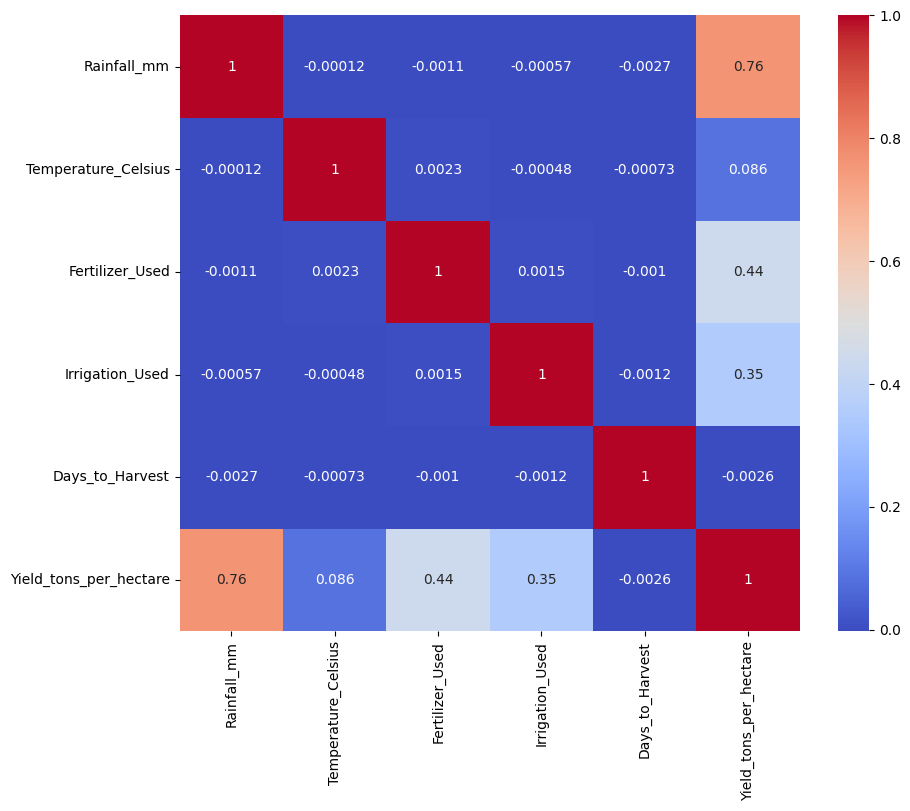

In [9]:
## Correlation heatmap
import seaborn as sns

## First selecting only the numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=['float64', 'int64', 'number', 'bool'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

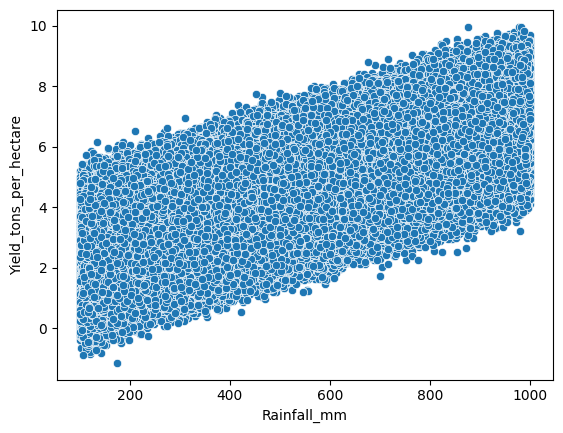

In [13]:
## Scatter plot to visualize the relationship between two variables
sns.scatterplot(
    x='Rainfall_mm', 
    y='Yield_tons_per_hectare',
    data=df
    )

plt.show()

In [18]:
## Separating the features and target variable
X = df.drop('Yield_tons_per_hectare', axis=1)
y = df['Yield_tons_per_hectare']

## Handling categorical variables using one-hot encoding
X = pd.get_dummies(
    X, 
    columns = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition'],
    drop_first=True
    )

## Converting boolean columns to integers
X['Fertilizer_Used'] = X['Fertilizer_Used'].astype(int)
X['Irrigation_Used'] = X['Irrigation_Used'].astype(int)

In [19]:
## Standardizing the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
## Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
## Training the linear regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

## Making predictions on the test set
y_pred = model.predict(X_test)

In [23]:
## Evaluating the model's performance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

MAE: 0.400
MSE: 0.251
RMSE: 0.501
R² Score: 0.913


In [ ]:
## 

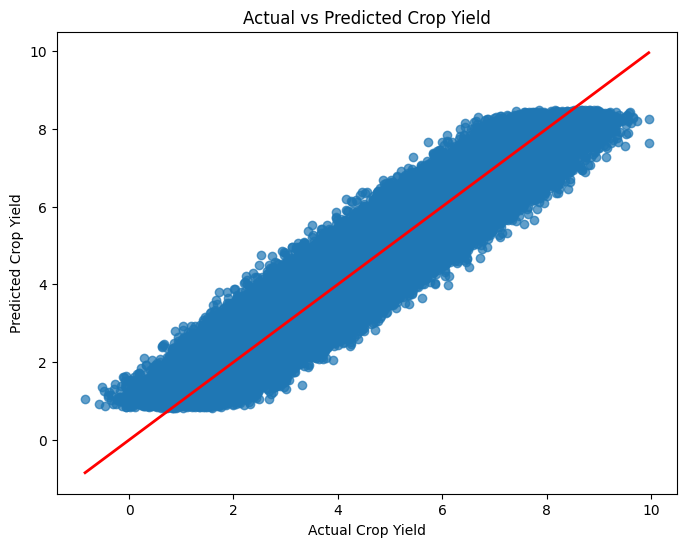

In [24]:
## Scatter plot to visualize the actual vs predicted crop yield

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Crop Yield")
plt.ylabel("Predicted Crop Yield")
plt.title("Actual vs Predicted Crop Yield")

plt.show()